# 电池状态折线图

读取 `Test2.xlsx`，以第一列（电压）为自变量，其余四列（电池状态）为因变量，绘制一张折线图。

遵循 dataviz 设计规范:
- 参考调色板 categorical 颜色（slots 1-4）
- 2px 折线 + 标记点 + surface ring
- 图例（≥2 系列始终显示）
- 淡色实线网格
- 端点直接标注（text tokens，不用 series color）
- 瘦标记 / 宽松留白


In [30]:
%matplotlib inline
%config InlineBackend.close_figures = False
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.font_manager import FontProperties
import os

In [31]:
# ── 中文字体 ──────────────────────────────────────────────
plt.rcParams["font.family"] = "Source Han Sans CN"
plt.rcParams["axes.unicode_minus"] = False

In [32]:
# ── 参考调色板 — categorical slots 1-4 ──
PALETTE = [
    "#2a78d6",  # 1 · blue
    "#1baf7a",  # 2 · aqua
    "#eda100",  # 3 · yellow
    "#008300",  # 4 · green
]

# Ink / chrome
INK_PRIMARY   = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED     = "#898781"
GRIDLINE      = "#e1e0d9"
BASELINE      = "#c3c2b7"
SURFACE       = "#fcfcfb"


In [33]:
# ── 读取数据 ──────────────────────────────────────────────
# notebook 环境中没有 __file__，改用当前工作目录定位数据文件
BASE = os.getcwd()
FILE = os.path.join(BASE, "Test2.xlsx")
df   = pd.read_excel(FILE)
x_col  = df.columns[0]               # "电压（V）"
y_cols = df.columns[1:].tolist()      # 4 列因变量

print(f"x 轴: {x_col}")
print(f"y 轴: {y_cols}")
print(f"数据行数: {len(df)}")


x 轴: 电压（V）
y 轴: ['新电池状态', '衰减状态1', '衰减状态2', '衰减状态3']
数据行数: 280


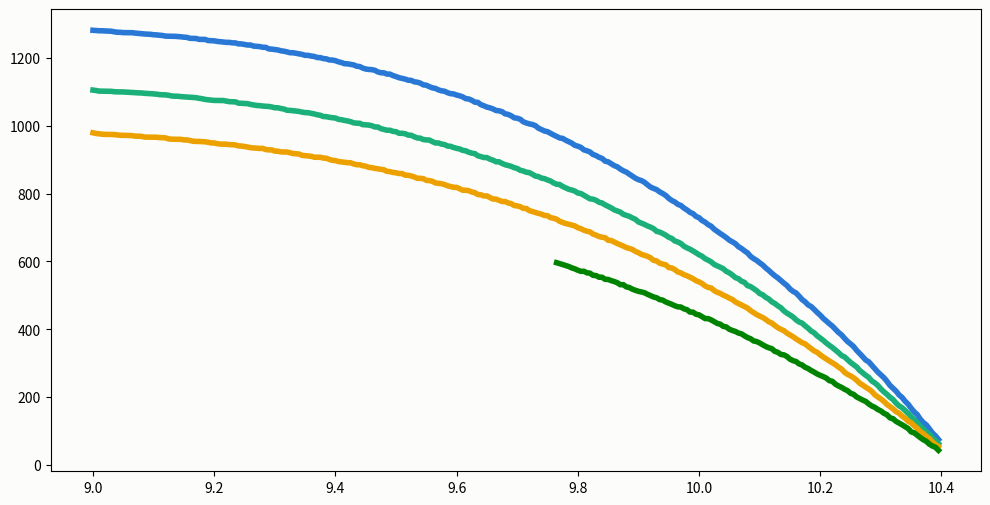

In [34]:
# ── 绘图 ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
fig.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

for i, y_col in enumerate(y_cols):
    color = PALETTE[i]
    x = df[x_col]
    y = df[y_col]

    # 折线 · 尖角连接 + 散点标记
    ax.plot(
        x, y,
        color=color,
        linewidth=4,
        solid_joinstyle="miter",       # 尖角连接
        marker="",
        markersize=6,                  # r=6 → 直径 12px，≥ 8px ✓
        markeredgewidth=2,
        markeredgecolor=SURFACE,       # surface ring ✓
        markerfacecolor=color,
        markevery=max(1, len(df) // 20),
        label=y_col,
        zorder=3,
    )


In [35]:
# ── 轴标签 & 标题 ────────────────────────────────────────
ax.set_xlabel(x_col, fontsize=12, color=INK_PRIMARY, labelpad=8)
ax.set_ylabel("电流 (A)", fontsize=12, color=INK_PRIMARY, labelpad=8)
ax.set_title(
    "电池状态随电压变化曲线",
    fontsize=15,
    fontweight="bold",
    color=INK_PRIMARY,
    pad=18,
)

# ── 网格（hairline · 实线 · 数据下方） ──────────────────
ax.grid(True, linestyle="solid", linewidth=0.5, color=GRIDLINE, zorder=0)
ax.set_axisbelow(True)

# 刻度
ax.tick_params(axis="both", colors=INK_MUTED, labelsize=9, direction="in")

# y 轴从 0 起
ymin, ymax = ax.get_ylim()
ax.set_ylim(bottom=0)

# x 轴反向（电压从高到低排列）
ax.invert_xaxis()


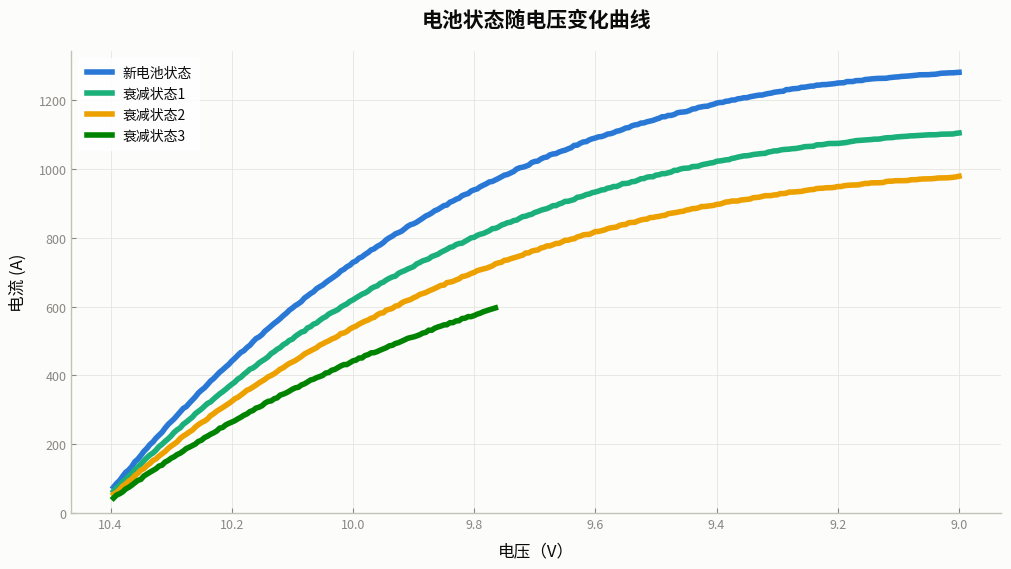

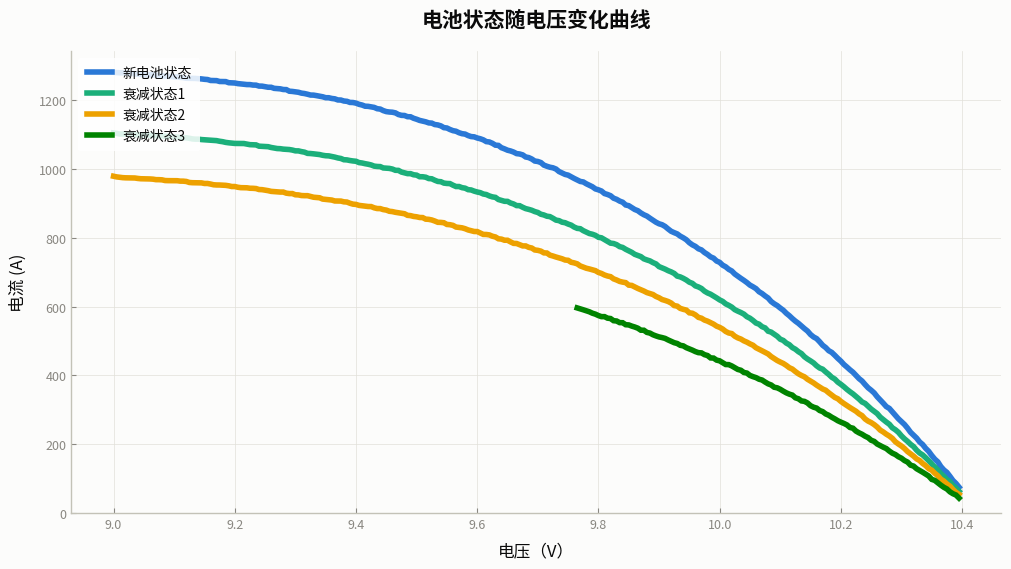

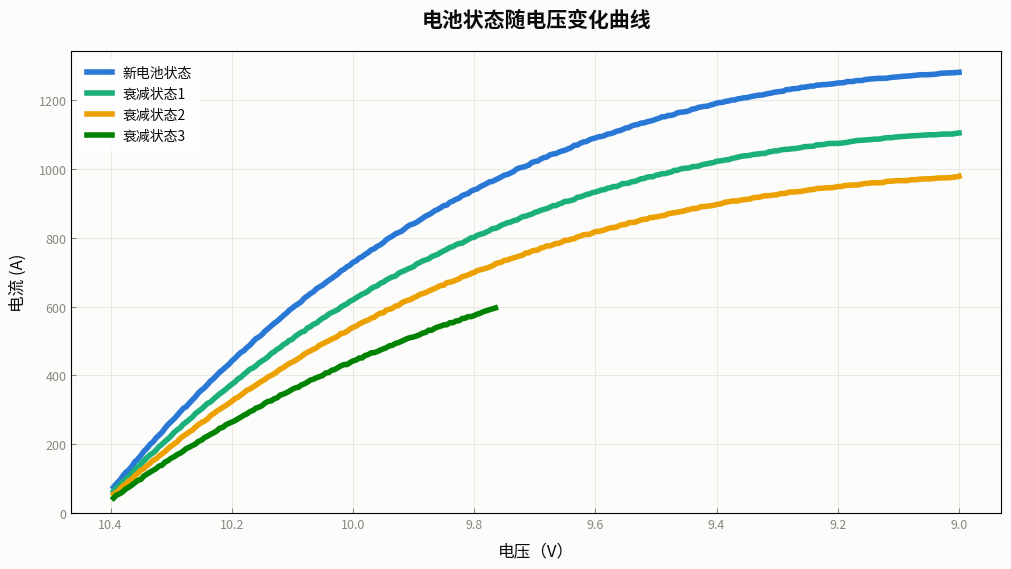

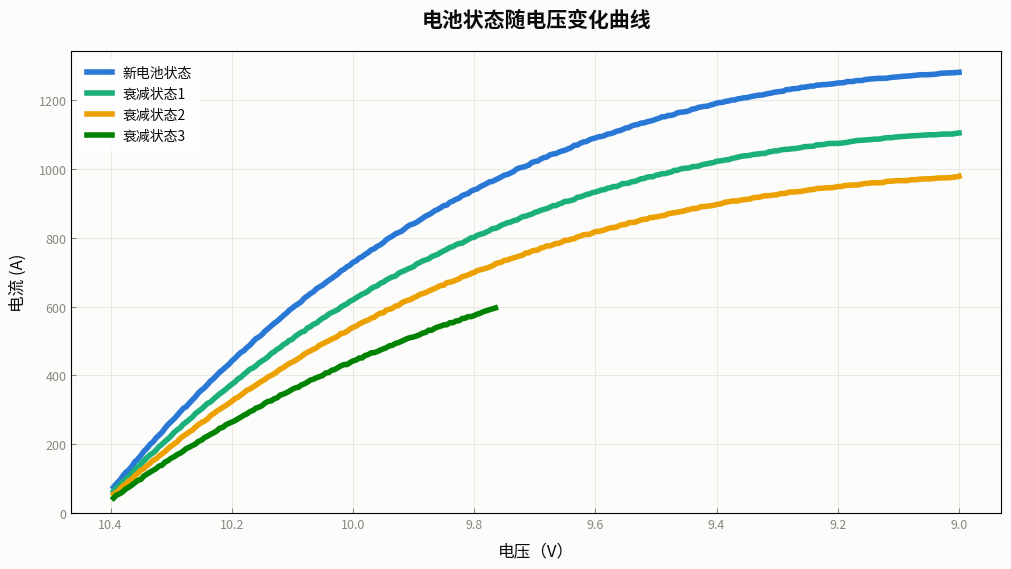

In [36]:
# ── 图例 ──────────────────────────────────────────────────
legend = ax.legend(
    loc="upper left",
    frameon=True,
    fontsize=10,
    facecolor="white",
    edgecolor="none",
    framealpha=0.85,
    borderpad=0.6,
    handlelength=1.8,
    handleheight=0.7,
)
for text in legend.get_texts():
    text.set_color(INK_PRIMARY)

# ── 显示最终图像 ─────────────────────────────────────────
plt.show()